# Data Analysis and Visualization

With the cleaned data which was all exported as CSV files, now the data can be filtered and analyzed. The first step is to join the tables. 

The first thing that has to be done is to isolate the subjects that are within the obesity range (BMI 30 kg/m^2 or greater). The focus will also be on adult subjects, thus aged 18 or older. 

The assumptions that are made include:
* NHANES dataset represents the American population

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
workingdirectory = os.getcwd()
print(workingdirectory)

C:\Users\Rachel\Documents\Github\portfolio_ds_projects\NHANES_analysis


In [3]:
os.chdir('C:/Users/Rachel/Documents/Github/portfolio_ds_projects/NHANES_analysis')

In [4]:
df_d = pd.read_csv('cleaned_demographics.csv')
df_a = pd.read_csv('cleaned_bodymeasures.csv')
df_b = pd.read_csv('cleaned_blood_labs_combined.csv')
df_u = pd.read_csv('cleaned_urine_labs_combined.csv')
df_h = pd.read_csv('cleaned_hep_labs_combined.csv')

Since the demographics data frame contains the age and the anthropometry data frame contains the BMI, they were each filtered first before the tables were joined.

In [5]:
df_d.head()

,participant_id,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109263.0,1.0,2.0,6.0,NaN,NaN,4.66
1,109264.0,2.0,13.0,1.0,NaN,NaN,0.83
2,109265.0,1.0,2.0,3.0,NaN,NaN,3.06
3,109266.0,2.0,29.0,6.0,5.0,3.0,5.00
4,109269.0,1.0,2.0,2.0,NaN,NaN,0.96


In [6]:
df_d = df_d[df_d['age_year'] >= 18]

In [7]:
adults = pd.merge(df_a, df_d, on='participant_id', how='inner')

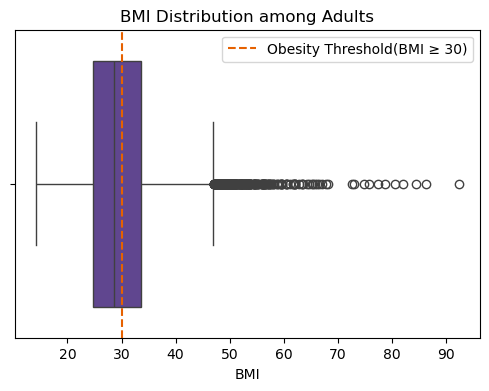

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults, color = '#5D3A9B')

plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold(BMI ≥ 30)")
plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend()
plt.show()

In [9]:
adults['bmi'].describe()

count    8790.000000
mean       29.883413
std         7.603916
min        14.200000
25%        24.700000
50%        28.600000
75%        33.600000
max        92.300000
Name: bmi, dtype: float64

The BMI rating is as follows:
* Underweight: Less than 18.5
* Normal weight: 18.5 to 24.9
* Overweight: 25 to 29.9
* Obesity: 30 to 39.9
* Morbidly obese: 40 or greater

As we can see, even at average, the weight distribution among adults doesn't fall into normal weight. In fact, the mean weight of this dataset, which is supposed to mimic the American population, is in the upper range of overweight bordering obesity. The weight of the Americans are overall increased.

However, there are significant outliers with values such as 92.3 which would increase average. To address the outlier, the decision was made to see how many subjects have BMI greater than 60.

In [10]:
num_high_bmi = (adults['bmi'] >= 60).sum()
print(f"Number of subjects with BMI >= 60: {num_high_bmi}")
prop_high_bmi = (adults['bmi'] >= 60).mean()
print(f"Proportion of subjects with BMI >= 60: {prop_high_bmi:.2%}")

Number of subjects with BMI >= 60: 36
Proportion of subjects with BMI >= 60: 0.41%


Out of the number of obese subjects, there are less than 1% of the dataset which have BMI equal to or greater thn 60. BMI of 60 is also not frequently encountered. Further elimination may be warranted. 

The decision was made to see how many subjects have BMI falling between 50 and 60.

In [11]:
# Count number of subjects with 50 <= BMI < 60
num_bmi_50_60 = ((adults['bmi'] >= 50) & (adults['bmi'] < 60)).sum()
print(f"Number of subjects with BMI between 50 and 60: {num_bmi_50_60}")
prop_bmi_50_60 = ((adults['bmi'] >= 50) & (adults['bmi'] < 60)).mean()
print(f"Proportion of subjects with BMI between 50 and 60: {prop_bmi_50_60:.2%}")

Number of subjects with BMI between 50 and 60: 135
Proportion of subjects with BMI between 50 and 60: 1.53%


Combining both of these values, the total proportion of adult subjects with BMI falling above 50 is 1.94%. The decision was made to drop those subjects whose BMI is greater than 50.

In [12]:
adults_filtered = adults[adults['bmi'] <= 50].copy()

In [13]:
adults_filtered['bmi'].describe()

count    8622.000000
mean       29.357237
std         6.583851
min        14.200000
25%        24.600000
50%        28.500000
75%        33.300000
max        50.000000
Name: bmi, dtype: float64

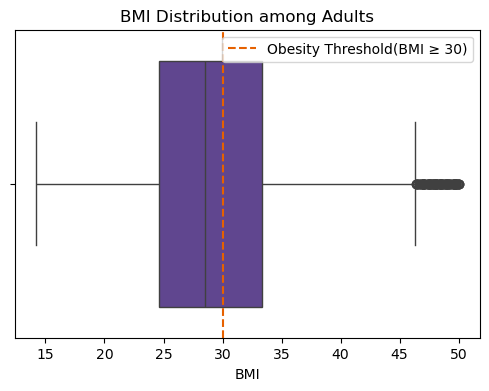

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x='bmi', data=adults_filtered, color = '#5D3A9B')

plt.axvline(30, color='#E66100', linestyle='--', label="Obesity Threshold(BMI ≥ 30)")
plt.title("BMI Distribution among Adults")
plt.xlabel("BMI")
plt.legend()
plt.show()

As we can see, even with the outliers removed, the average weight of the subjects in this dataset still falls in the overweight range. The overall weight has increased in the American population.

In [15]:
obese = df_a[df_a['bmi'] >= 30]

In [16]:
obese_adults = adults_filtered.merge(obese, on='participant_id', suffixes=("", "_drop"))

In [17]:
obese_adults.shape

(3520, 31)

In [18]:
obese_adults.head()

,participant_id,weight_kg,weight_comment,recumbent_length_cm,standing_height,standing_height_comment,bmi,bmi_category_child,upper_leg_cm,upper_arm_cm,...,recumbent_length_cm_drop,standing_height_drop,standing_height_comment_drop,bmi_drop,bmi_category_child_drop,upper_leg_cm_drop,upper_arm_cm_drop,arm_circumference_cm_drop,waist_circ_cm_drop,hip_circ_cm_drop
0,109266.0,97.1,NaN,NaN,160.2,NaN,37.8,NaN,40.8,34.7,...,NaN,160.2,NaN,37.8,NaN,40.8,34.7,35.8,117.9,126.1
1,109274.0,103.7,NaN,NaN,185.3,NaN,30.2,NaN,44.0,47.0,...,NaN,185.3,NaN,30.2,NaN,44.0,47.0,32.0,109.6,107.8
2,109284.0,91.1,NaN,NaN,152.7,NaN,39.1,NaN,33.0,33.5,...,NaN,152.7,NaN,39.1,NaN,33.0,33.5,38.5,103.1,125.5
3,109291.0,81.4,3.0,NaN,161.3,NaN,31.3,NaN,NaN,NaN,...,NaN,161.3,NaN,31.3,NaN,NaN,NaN,NaN,NaN,NaN
4,109292.0,86.0,NaN,NaN,167.8,NaN,30.5,NaN,38.4,39.5,...,NaN,167.8,NaN,30.5,NaN,38.4,39.5,29.0,108.3,106.4


In [19]:
obese_adults = obese_adults[obese_adults.columns.drop(list(obese_adults.filter(regex='_drop$')))]

There are 3520 adult subjects who are obese.

In [20]:
obese_adults.columns

Index(['participant_id', 'weight_kg', 'weight_comment', 'recumbent_length_cm',
       'standing_height', 'standing_height_comment', 'bmi',
       'bmi_category_child', 'upper_leg_cm', 'upper_arm_cm',
       'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm', 'gender',
       'age_year', 'race', 'education_level', 'marital_status',
       'family_income_poverty'],
      dtype='object')

In [21]:
obese_adults = obese_adults.drop(['weight_kg','weight_comment', 'recumbent_length_cm','standing_height',
                                  'standing_height_comment', 'bmi_category_child', 'upper_leg_cm', 
                                  'upper_arm_cm', 'arm_circumference_cm', 'waist_circ_cm', 'hip_circ_cm',], axis = 1)

In [22]:
obese_adults.head()

,participant_id,bmi,gender,age_year,race,education_level,marital_status,family_income_poverty
0,109266.0,37.8,2.0,29.0,6.0,5.0,3.0,5.0
1,109274.0,30.2,1.0,68.0,7.0,4.0,3.0,1.2
2,109284.0,39.1,2.0,44.0,1.0,2.0,1.0,NaN
3,109291.0,31.3,2.0,42.0,6.0,5.0,1.0,NaN
4,109292.0,30.5,1.0,58.0,2.0,3.0,2.0,1.6


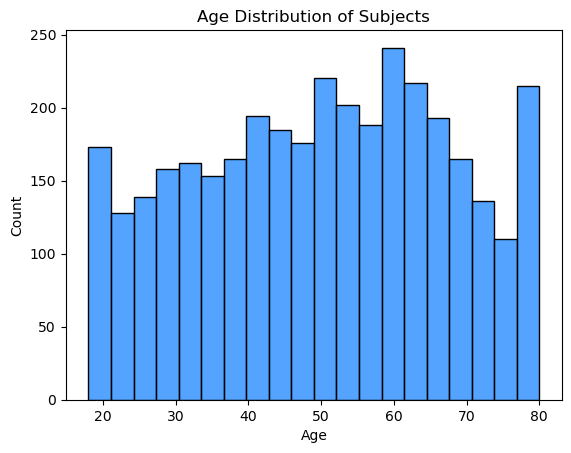

In [23]:
sns.histplot(x='age_year', bins = 20, data=obese_adults, color = '#1A85FF')
plt.title('Age Distribution of Subjects')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

The age distribution histogram seems to show that the general trend seems to be that as people age from their early 20s to early 60s, the obesity trend seems to peak and decrease until they get to late 70s. However, the trend appears to be quite weak. 

## Urine Labs

The next step is to analyze whether there is a correlation between urine lab results and obesity. 

In [24]:
obese_urine = obese_adults.merge(df_u, on='participant_id')

In [25]:
obese_urine.head()

,participant_id,bmi,gender,age_year,race,education_level,marital_status,family_income_poverty,albumin_urine_ug_mL,albumin_urine_mg_L,...,phenylglyoxylic_acid_ng_ml,phenylglyoxylic_acid_comment,n_acetyl_s_3_hydroxypropyl_1_methyl_l_cysteine_ng_ml,n_acetyl_s_3_hydroxypropyl_1_methyl_l_cysteine_comment,2_thioxothiazolidine_4_carboxylic_acid,2_thioxothiazolidine_4_carboxylic_acid_comment,trans_trans_muconic_acid_ng_ml,trans_trans_muconic_acid_comment,phenylmercapturic_acid_ng_ml,phenylmercapturic_acid_comment
0,109266.0,37.8,2.0,29.0,6.0,5.0,3.0,5.00,5.5,5.5,...,75.6,0.0,60.6,0.0,7.9,1.0,6.94,1.0,0.106,1.0
1,109274.0,30.2,1.0,68.0,7.0,4.0,3.0,1.20,12.8,12.8,...,230.0,0.0,2350.0,0.0,37.2,0.0,244.00,0.0,0.171,0.0
2,109284.0,39.1,2.0,44.0,1.0,2.0,1.0,NaN,8.2,8.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109291.0,31.3,2.0,42.0,6.0,5.0,1.0,NaN,16.4,16.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,109293.0,30.1,1.0,44.0,3.0,3.0,3.0,0.02,7.2,7.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
obese_urine.isna().sum()

participant_id                                       0
bmi                                                  0
gender                                               0
age_year                                             0
race                                                 0
                                                  ... 
2_thioxothiazolidine_4_carboxylic_acid_comment    2401
trans_trans_muconic_acid_ng_ml                    2496
trans_trans_muconic_acid_comment                  2496
phenylmercapturic_acid_ng_ml                      2496
phenylmercapturic_acid_comment                    2496
Length: 136, dtype: int64

In [27]:
obese_urine = obese_urine[obese_urine.columns.drop(list(obese_urine.filter(regex='_comment$')))]

In [28]:
obese_urine.shape

(3480, 74)

In [29]:
obese_urine.corr()

,participant_id,bmi,gender,age_year,race,education_level,marital_status,family_income_poverty,albumin_urine_ug_mL,albumin_urine_mg_L,...,n_acetyl_s_2_hydroxypropyl_l_cysteine_ng_ml,n_acetyl_s_3_hydroxypropyl_l_cysteine_ng_ml,n_acetyl_s_4_hydroxy_2_methyl_2_butenyl_l_cysteine_ng_ml,mandelic_acid_ng_ml,n_acetyl_s_4_hydroxy_2_butenyl_l_cysteine_ng_ml,phenylglyoxylic_acid_ng_ml,n_acetyl_s_3_hydroxypropyl_1_methyl_l_cysteine_ng_ml,2_thioxothiazolidine_4_carboxylic_acid,trans_trans_muconic_acid_ng_ml,phenylmercapturic_acid_ng_ml
participant_id,1.000000,-0.045338,-0.044235,-0.009823,0.011914,-0.008951,-0.002482,0.006778,-0.021304,-0.021304,...,-0.003982,0.064750,0.080985,0.065759,0.085150,0.118958,0.070003,-0.013466,0.019568,0.037658
bmi,-0.045338,1.000000,0.128417,-0.081592,0.028319,0.020379,0.021875,-0.076439,0.036294,0.036294,...,0.021967,-0.012135,-0.027235,-0.009345,-0.014694,-0.016589,-0.021767,0.020925,-0.024960,0.003001
gender,-0.044235,0.128417,1.000000,-0.010643,0.020578,0.006519,0.046041,-0.125995,-0.020529,-0.020529,...,-0.013366,-0.077283,-0.030488,-0.138960,-0.047421,-0.132940,-0.072459,0.002227,-0.070086,-0.051606
age_year,-0.009823,-0.081592,-0.010643,1.000000,-0.010469,-0.052416,-0.033042,0.118398,0.030650,0.030650,...,-0.029004,-0.079348,-0.075530,-0.114466,-0.087491,-0.058652,-0.065220,0.040165,-0.025592,-0.065749
race,0.011914,0.028319,0.020578,-0.010469,1.000000,0.223227,0.067495,0.034268,-0.010066,-0.010066,...,0.055509,0.069139,0.058016,0.051086,0.060820,0.084419,0.064326,0.029918,-0.049556,0.043911
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
phenylglyoxylic_acid_ng_ml,0.118958,-0.016589,-0.132940,-0.058652,0.084419,-0.014837,0.007483,-0.089370,-0.001561,-0.001561,...,0.257913,0.573897,0.520313,0.777093,0.588651,1.000000,0.586048,0.091147,0.165776,0.537107
n_acetyl_s_3_hydroxypropyl_1_methyl_l_cysteine_ng_ml,0.070003,-0.021767,-0.072459,-0.065220,0.064326,-0.042782,0.008082,-0.117425,-0.010490,-0.010490,...,0.324909,0.954780,0.916229,0.680399,0.931295,0.586048,1.000000,0.097688,0.145007,0.747925
2_thioxothiazolidine_4_carboxylic_acid,-0.013466,0.020925,0.002227,0.040165,0.029918,0.057907,-0.023273,-0.035213,0.009317,0.009317,...,0.033932,0.123245,0.071624,0.096726,0.082114,0.091147,0.097688,1.000000,0.026244,0.067600
trans_trans_muconic_acid_ng_ml,0.019568,-0.024960,-0.070086,-0.025592,-0.049556,-0.072670,0.005211,-0.073777,0.003779,0.003779,...,0.045111,0.146289,0.127430,0.193472,0.136981,0.165776,0.145007,0.026244,1.000000,0.118181


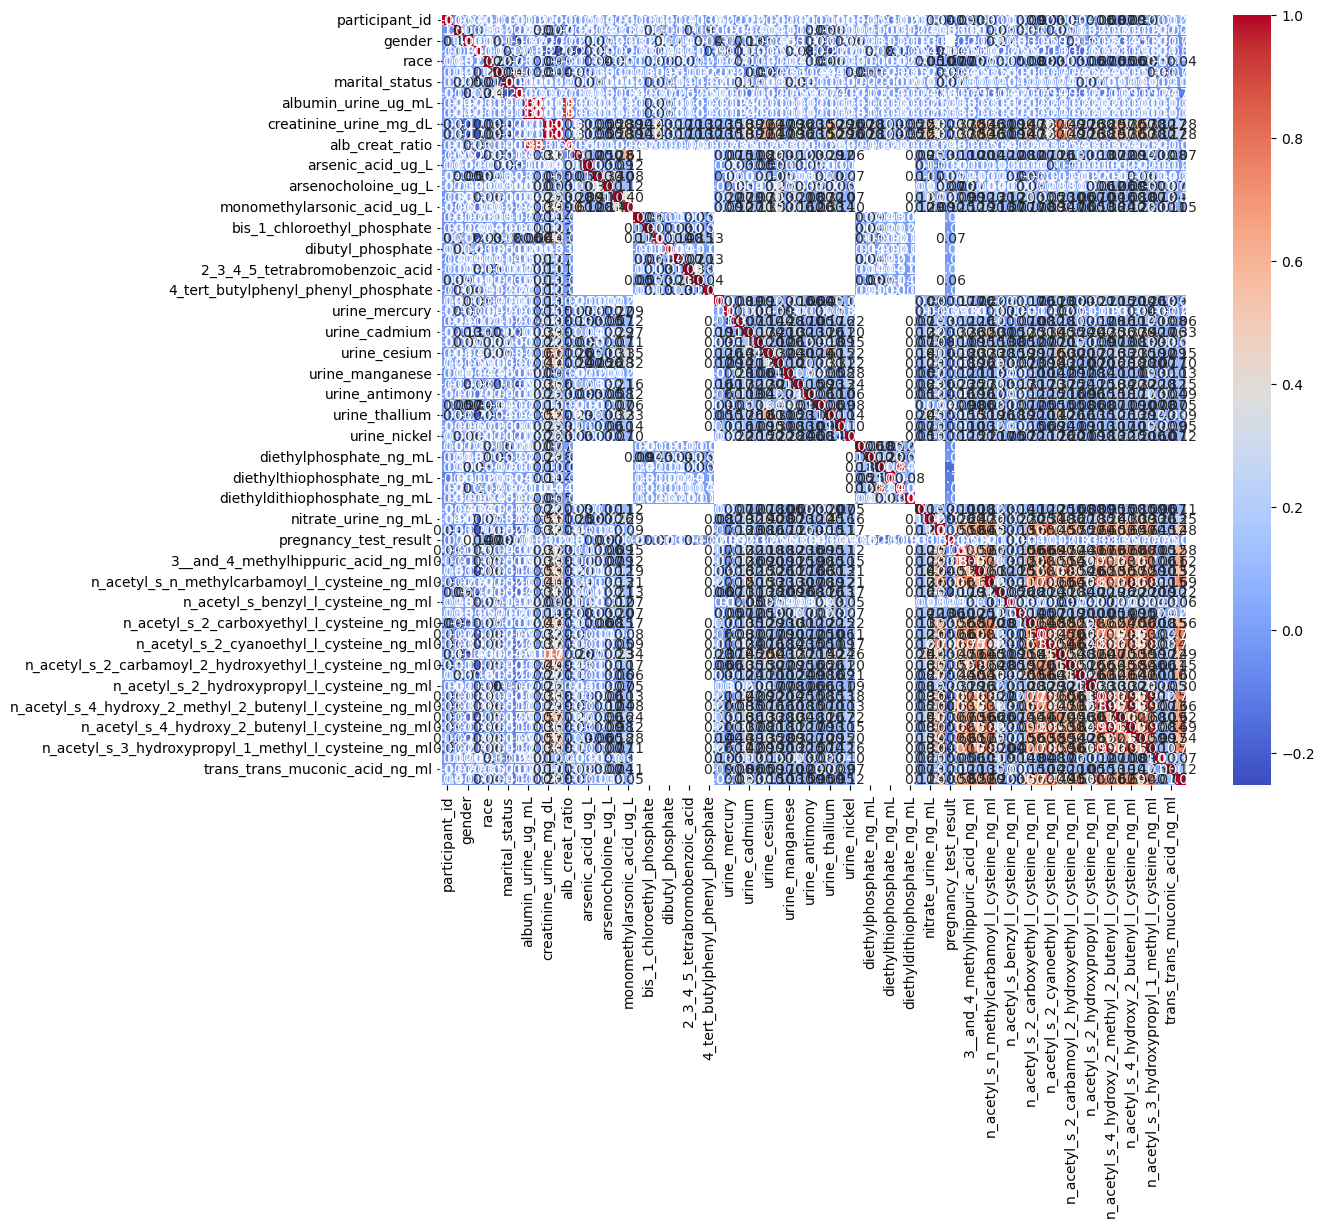

In [30]:
corr_matrix = obese_urine.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [34]:
corr_w_bmi = obese_urine.corrwith(obese_adults['bmi'])

In [38]:
strong_corr = corr_w_bmi[(corr_w_bmi <= -0.25) | (corr_w_bmi >= 0.25)]

print(strong_corr)

Series([], dtype: float64)


It appears that no urine test has any correlation with BMI. 

## Blood Labs

In [39]:
obese_blood = obese_adults.merge(df_b, on='participant_id')

In [40]:
obese_blood.head()

,participant_id,bmi,gender,age_year,race,education_level,marital_status,family_income_poverty,alpha_1_agp_g_l,direct_hdl_mg_dl,...,blood_aaa_trifluorotoluene_ng_ml,blood_aaa_trifluorotoluene_comment_code,blood_tetrahydrofuran_ng_ml,blood_tetrahydrofuran_comment_code,blood_123_trichloropropane_ng_ml,blood_123_trichloropropane_comt_code,blood_vinyl_bromide_ng_ml,blood_vinyl_bromide_comment_code,blood_m__p_xylene_ng_ml,blood_m__p_xylene_comment_code
0,109266.0,37.8,2.0,29.0,6.0,5.0,3.0,5.0,0.796,56.0,...,0.028,1.0,0.088,1.0,0.028,1.0,0.032,1.0,0.035,0.0
1,109274.0,30.2,1.0,68.0,7.0,4.0,3.0,1.2,NaN,29.0,...,0.028,1.0,0.088,1.0,0.028,1.0,0.032,1.0,0.024,1.0
2,109284.0,39.1,2.0,44.0,1.0,2.0,1.0,NaN,1.080,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109291.0,31.3,2.0,42.0,6.0,5.0,1.0,NaN,0.766,51.0,...,0.028,1.0,0.088,1.0,0.028,1.0,0.032,1.0,0.036,0.0
4,109292.0,30.5,1.0,58.0,2.0,3.0,2.0,1.6,NaN,52.0,...,0.028,1.0,0.088,1.0,0.028,1.0,0.032,1.0,0.061,0.0


In [41]:
obese_blood = obese_blood[obese_blood.columns.drop(list(obese_blood.filter(regex='_comment$')))]

In [44]:
obese_blood.isna().sum()

participant_id                             0
bmi                                        0
gender                                     0
age_year                                   0
race                                       0
                                        ... 
blood_123_trichloropropane_comt_code    1796
blood_vinyl_bromide_ng_ml               1796
blood_vinyl_bromide_comment_code        1796
blood_m__p_xylene_ng_ml                 1797
blood_m__p_xylene_comment_code          1797
Length: 269, dtype: int64

In [45]:
numeric_cols = obese_blood.select_dtypes('number').columns
df_numeric = obese_blood[numeric_cols].loc[:, obese_blood[numeric_cols].nunique() > 1]

In [47]:
corr_b_bmi = df_numeric.corrwith(obese_adults['bmi'])

In [48]:
strong_corr = corr_b_bmi[(corr_b_bmi <= -0.25) | (corr_b_bmi >= 0.25)]

print(strong_corr)

Series([], dtype: float64)
